In [16]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        print(os.path.join(dirname, file))

/kaggle/input/datasets/sachin7740/loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv
/kaggle/input/datasets/sachin7740/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv


In [17]:
import pandas as pd

train = pd.read_csv('/kaggle/input/datasets/sachin7740/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv')

test = pd.read_csv('/kaggle/input/datasets/sachin7740/loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv')

print(train.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [18]:
# Check missing values

print(train.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [19]:
# Fill missing values

train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)

train['Married'].fillna(train['Married'].mode()[0], inplace=True)

train['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)

train['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)

train['LoanAmount'].fillna(train['LoanAmount'].mean(), inplace=True)

train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mean(), inplace=True)

train['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)

# Convert categorical columns into numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status', 'Dependents']

for col in cols:
    train[col] = le.fit_transform(train[col])

# Show cleaned data

print(train.head())

    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       1        0           0          0              0   
1  LP001003       1        1           1          0              0   
2  LP001005       1        1           0          0              1   
3  LP001006       1        1           0          1              0   
4  LP001008       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0  146.412162             360.0   
1             4583             1508.0  128.000000             360.0   
2             3000                0.0   66.000000             360.0   
3             2583             2358.0  120.000000             360.0   
4             6000                0.0  141.000000             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1             1.0              0            0  
2       

/tmp/ipykernel_117/2588453539.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_117/2588453539.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [20]:
# Split data into X and y

X = train.drop(['Loan_ID', 'Loan_Status'], axis=1)

y = train['Loan_Status']

# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Accuracy

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7723577235772358


In [21]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

print("Confusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))

Confusion Matrix:

[[18 25]
 [ 3 77]]


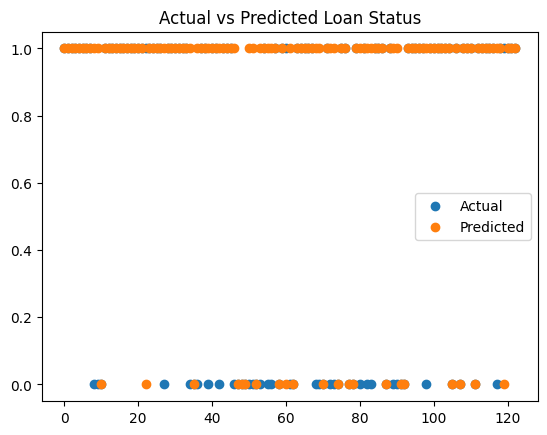

In [22]:
import matplotlib.pyplot as plt

# Actual vs Predicted plot

plt.scatter(range(len(y_test)), y_test, label='Actual')

plt.scatter(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Loan Status")

plt.show()